In [12]:
import matplotlib.pyplot as plt

In [2]:
from keras.applications.vgg16 import VGG16
#Load the model
model = VGG16()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 108s 0us/step


In [3]:
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 4096)                │     102,764,544 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
from keras.utils import plot_model

plot_model(model)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [5]:
for i in range(len(model.layers)):
	# check for convolutional layer
	if 'conv' not in model.layers[i].name:
		continue
	# get filter weights
	filters, biases = model.layers[i].get_weights()
	print("layer number",i,model.layers[i].name, filters.shape)

layer number 1 block1_conv1 (3, 3, 3, 64)
layer number 2 block1_conv2 (3, 3, 64, 64)
layer number 4 block2_conv1 (3, 3, 64, 128)
layer number 5 block2_conv2 (3, 3, 128, 128)
layer number 7 block3_conv1 (3, 3, 128, 256)
layer number 8 block3_conv2 (3, 3, 256, 256)
layer number 9 block3_conv3 (3, 3, 256, 256)
layer number 11 block4_conv1 (3, 3, 256, 512)
layer number 12 block4_conv2 (3, 3, 512, 512)
layer number 13 block4_conv3 (3, 3, 512, 512)
layer number 15 block5_conv1 (3, 3, 512, 512)
layer number 16 block5_conv2 (3, 3, 512, 512)
layer number 17 block5_conv3 (3, 3, 512, 512)


In [6]:
# retrieve weights from the second hidden layer
filters , bias = model.layers[1].get_weights()

In [7]:
# normalize filter values to 0-1 so we can visualize them
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


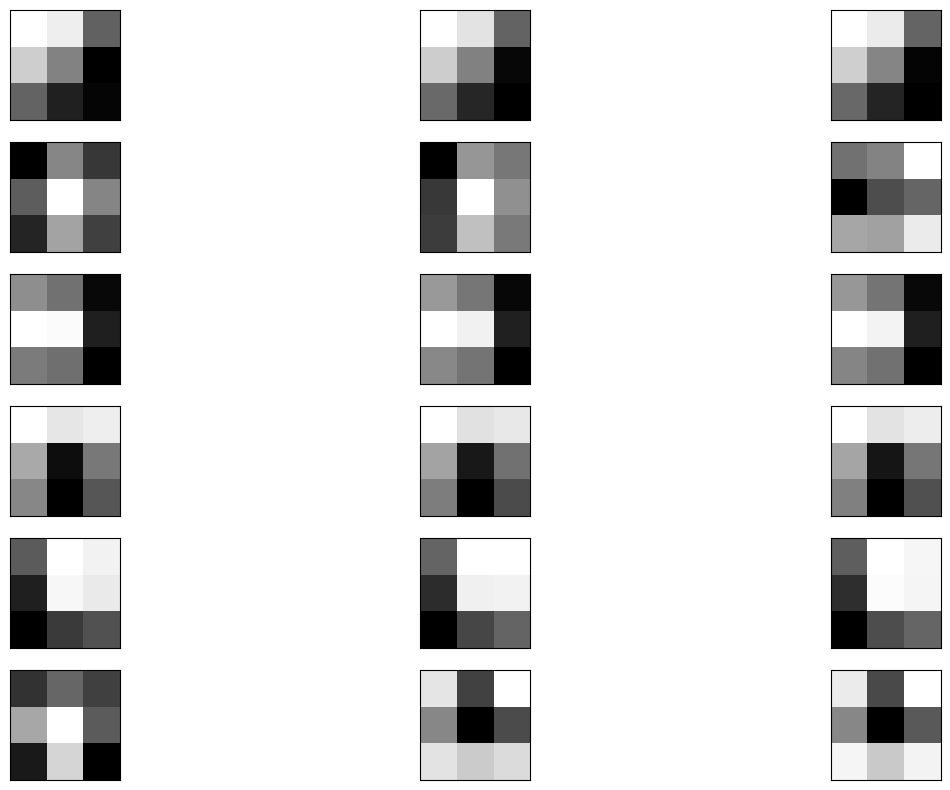

In [14]:
import matplotlib.pyplot as plt
from keras.applications.vgg16 import VGG16

# 1. Model load karein
model = VGG16(weights='imagenet', include_top=False)

# 2. First Convolutional Layer (block1_conv1) ke filters extract karein
filters, biases = model.layers[1].get_weights()

# 3. Filters ko normalize karein (0-1 range mein taaki imshow properly display kare)
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

# 4. Aapka Visualization Code (with `pyplot` as `plt`)
n_filters = 6
ix = 1
fig = plt.figure(figsize=(15, 10))

for i in range(n_filters):
    # Get the i-th filter
    f = filters[:, :, :, i]
    
    # Plot for all 3 color channels (R, G, B)
    for j in range(3):
        # Subplot for 6 filters and 3 channels
        ax = plt.subplot(n_filters, 3, ix)
        ax.set_xticks([]) # Grid lines aur axis ticks hide karne ke liye
        ax.set_yticks([])
        
        plt.imshow(f[:, :, j], cmap='gray')
        ix += 1

# Plot display karein
plt.show()

In [16]:
from keras.models import Model

feature_extractor = Model(inputs=model.input, outputs=model.layers[1].output)

In [23]:
from numpy import expand_dims
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.utils import img_to_array, load_img

# Aapka code execution:
image = load_img('1494661.jpg', target_size=(224, 224))
image = img_to_array(image)
image = expand_dims(image, axis=0)
image = preprocess_input(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


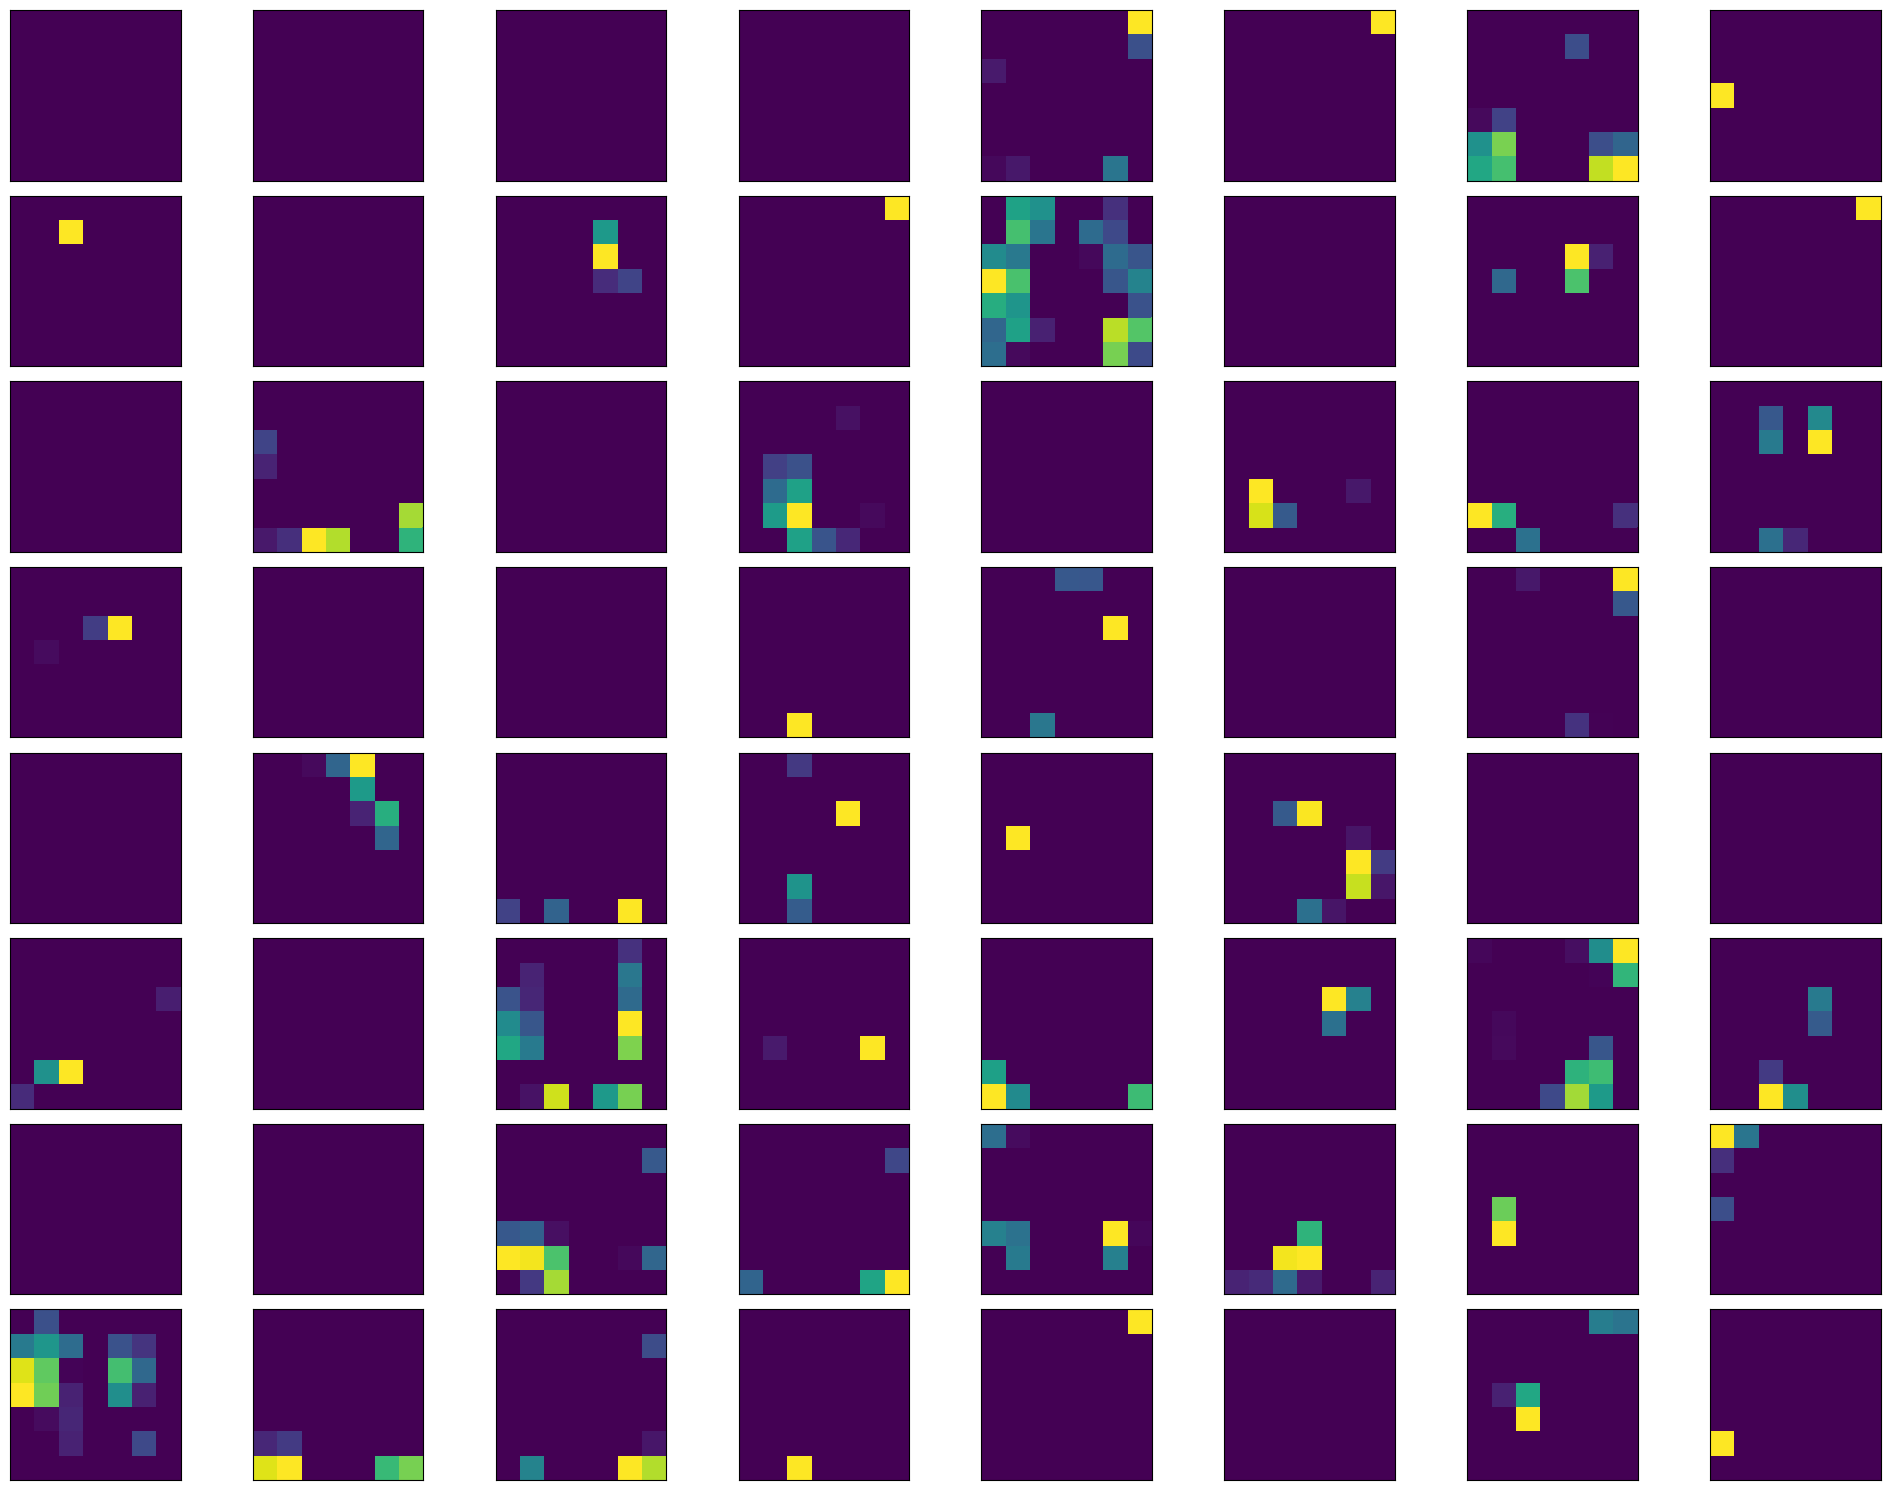

In [29]:
#calculating features_map
import matplotlib.pyplot as plt

features = model.predict(image)

# Total channels ya maximum 64, dono mein se jo kam ho
num_features = min(features.shape[3], 64)

fig = plt.figure(figsize=(20, 15))

for i in range(1, num_features + 1):
    ax = plt.subplot(8, 8, i)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.imshow(features[0, :, :, i - 1], cmap='viridis')

plt.tight_layout()
plt.show()

In [30]:
model2 = VGG16()

In [31]:
layer_index = [ 2, 5 , 9 , 13 , 17]
outputs = [model2.layers[i].output for i in layer_index]

model3 = Model( inputs= model2.inputs, outputs = outputs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


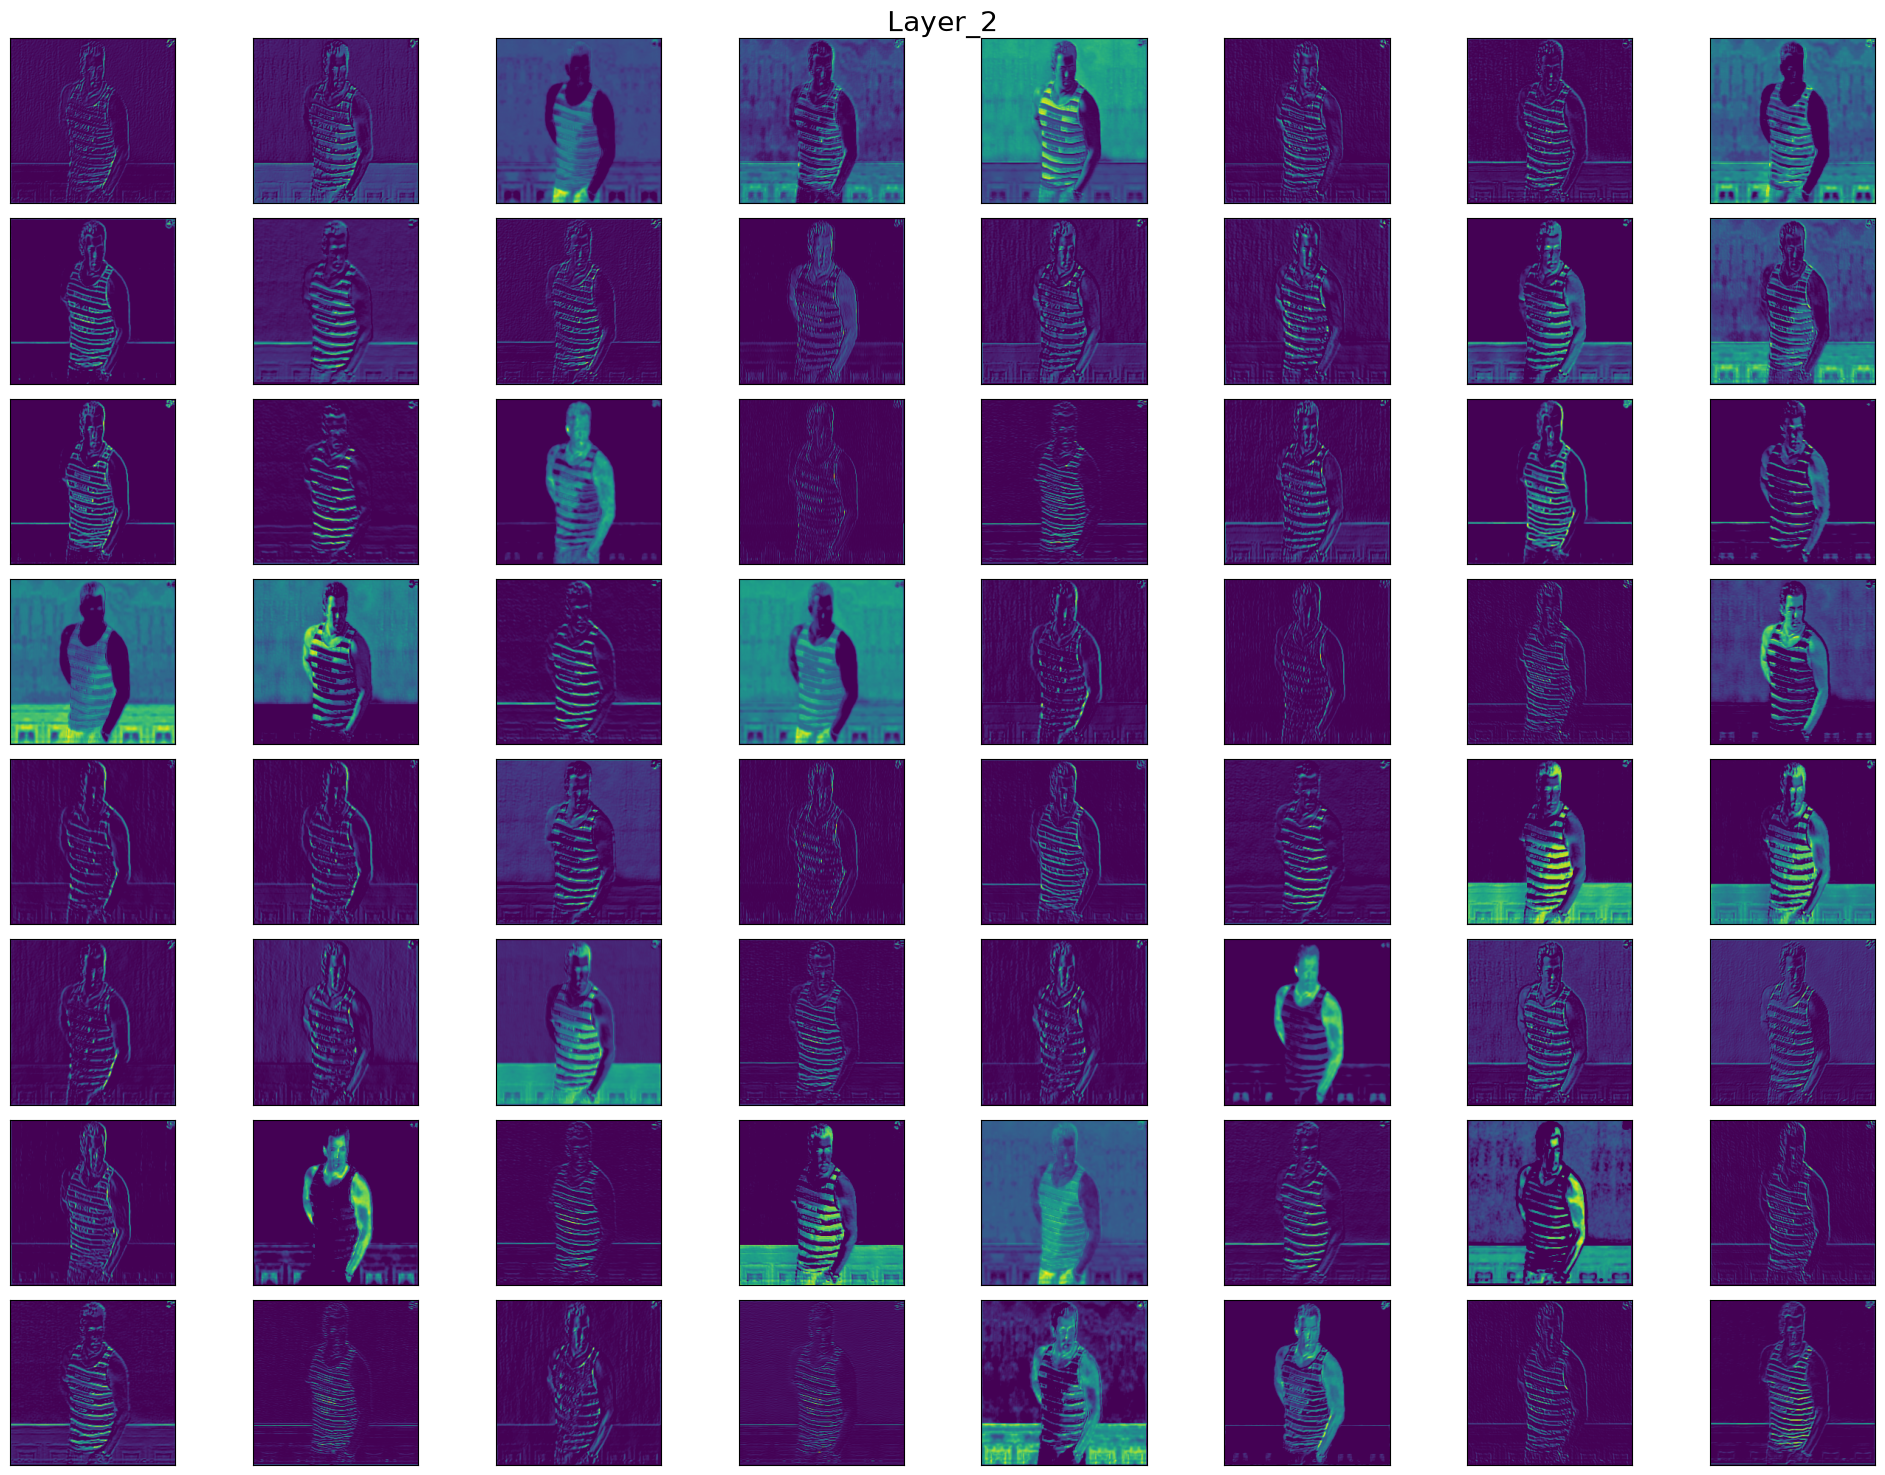

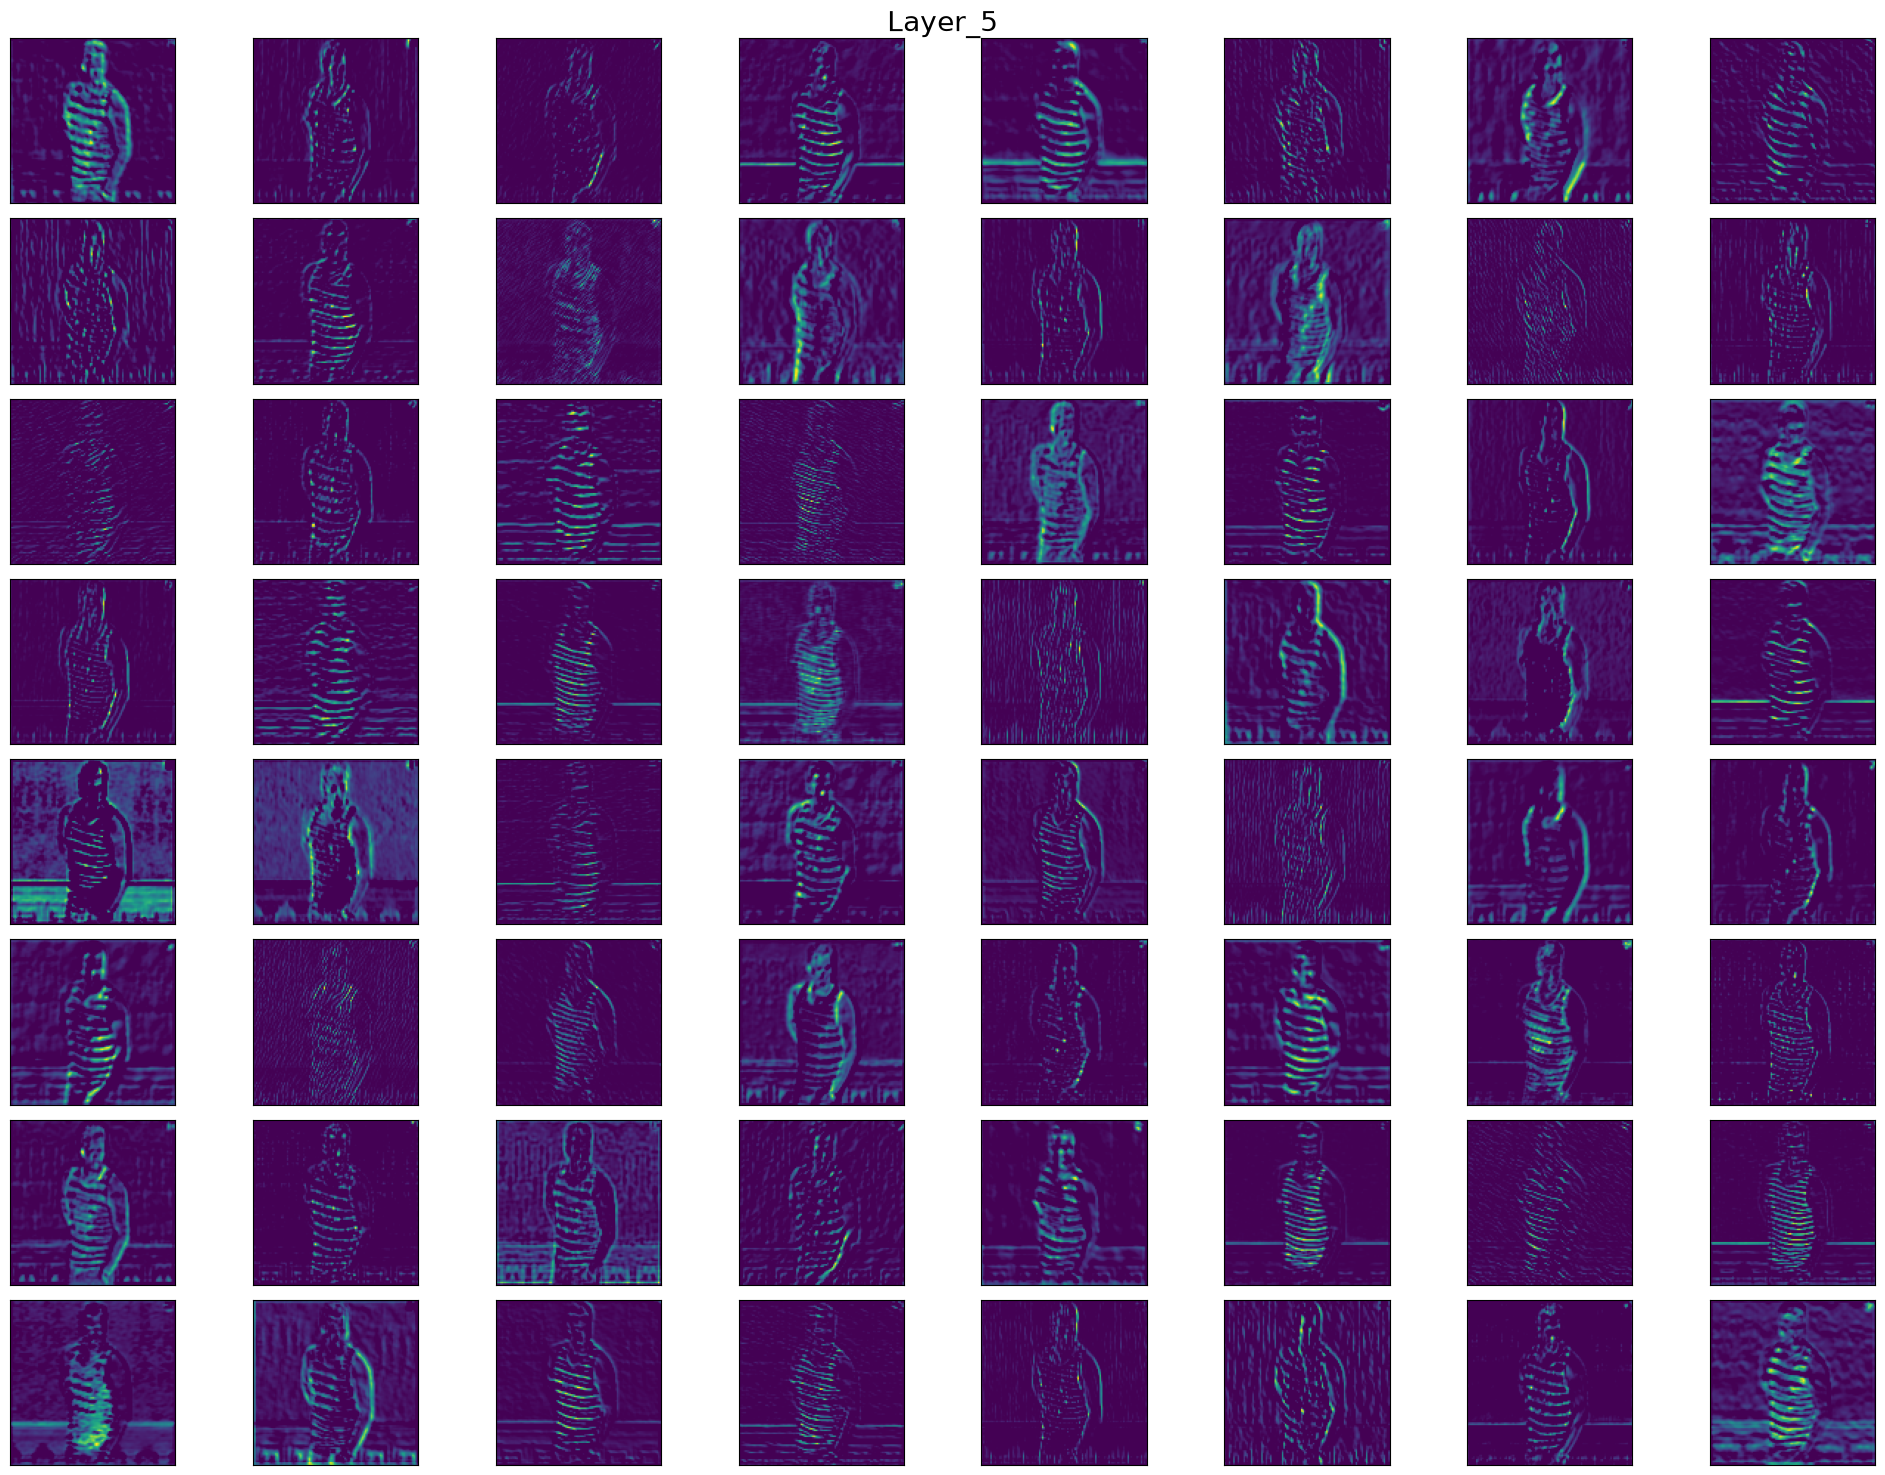

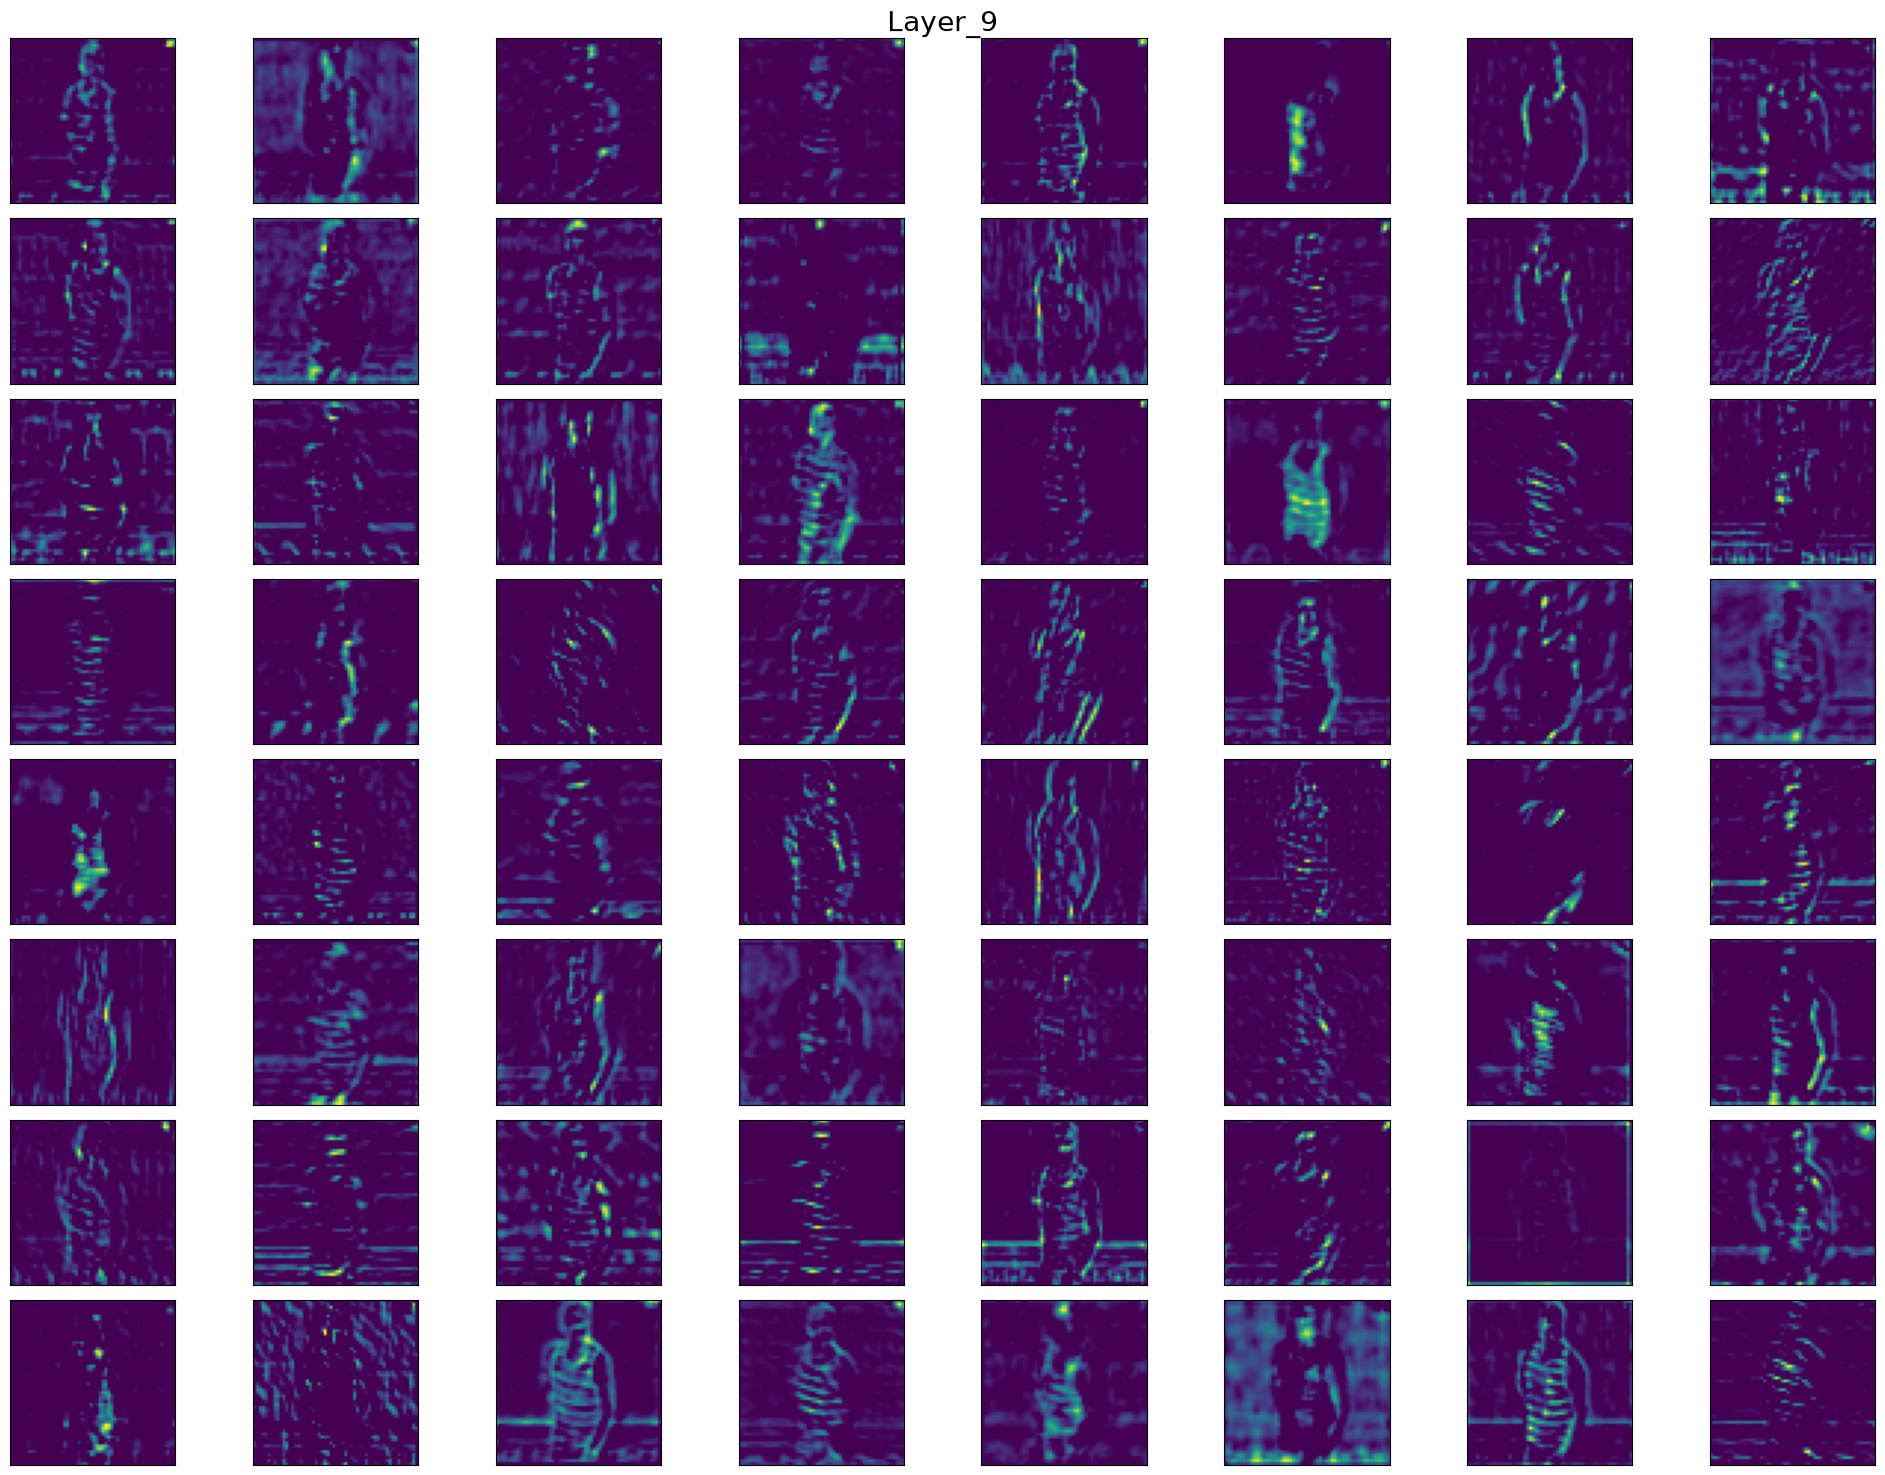

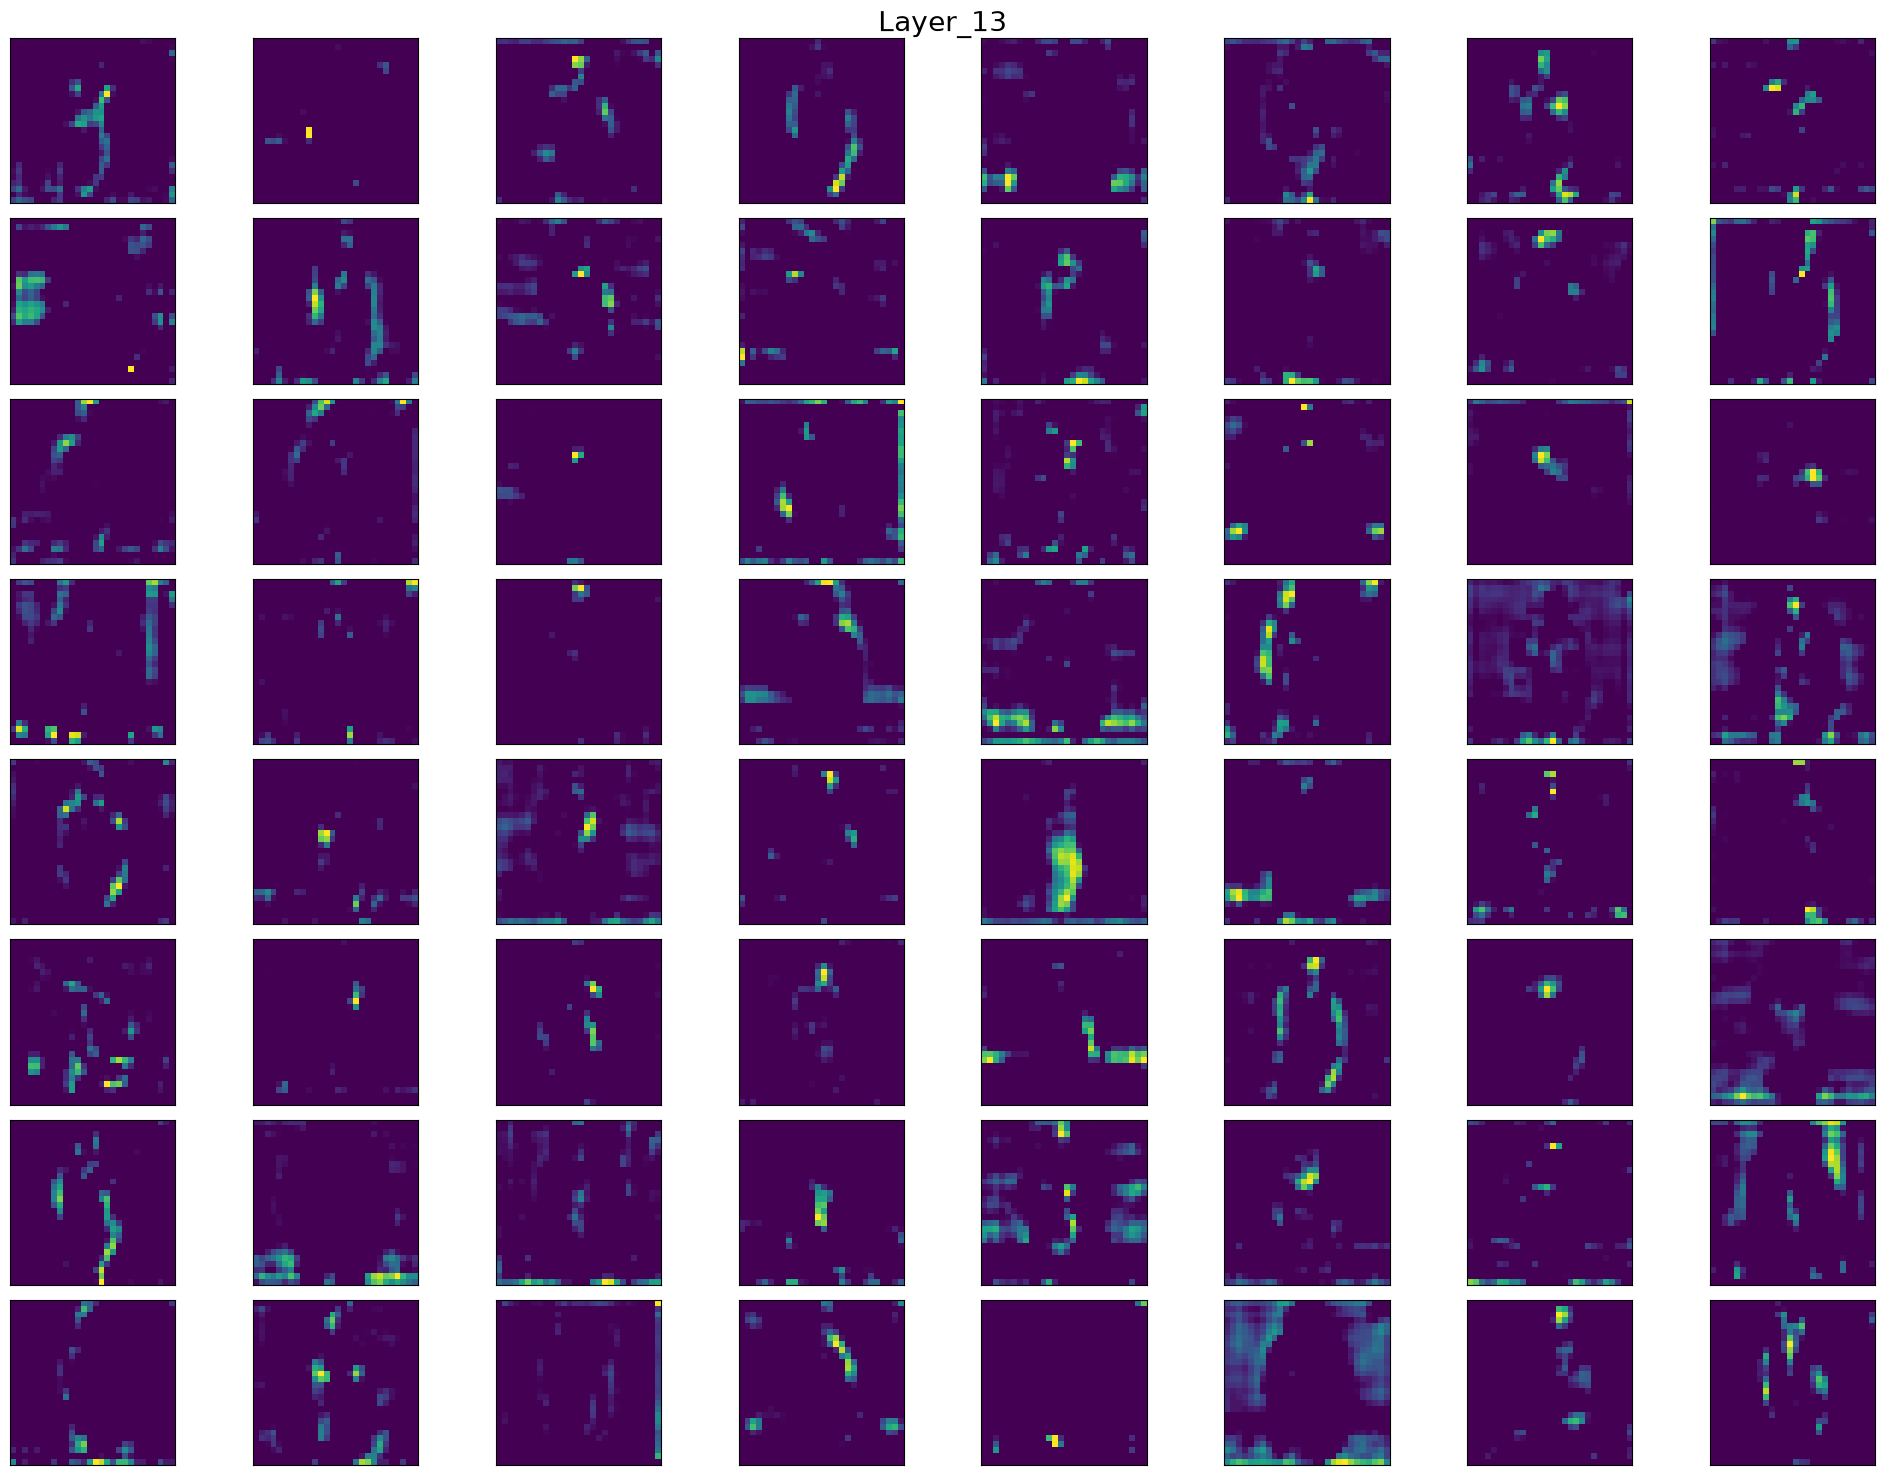

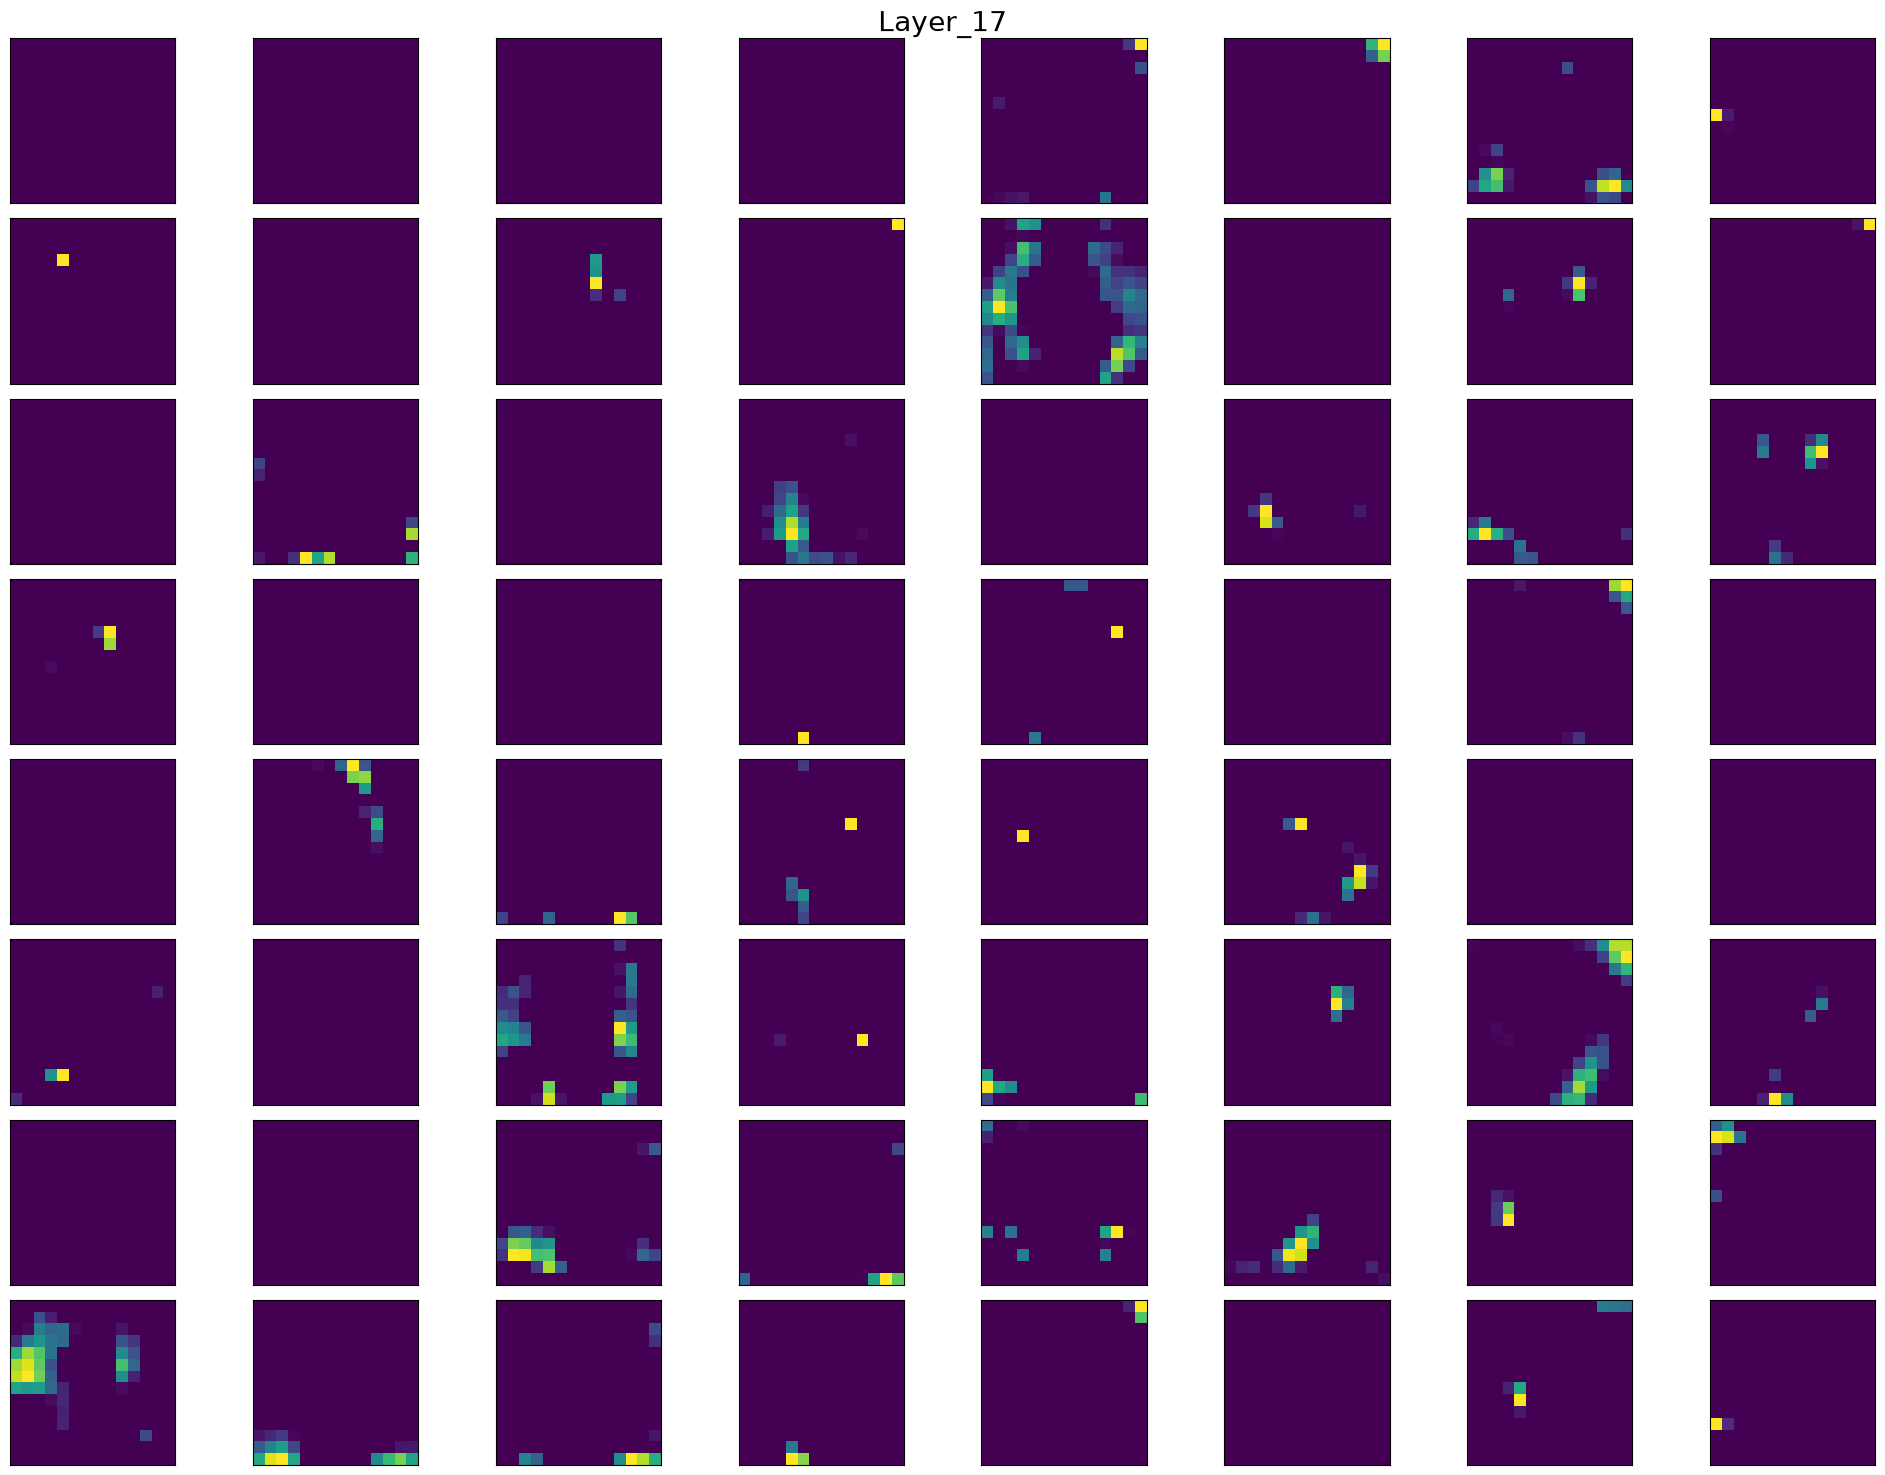

In [34]:
import matplotlib.pyplot as plt

# 1. Prediction (Model multi-output hona chahiye)
feature_maps = model3.predict(image)

# 2. Iterate through layers and their feature maps
for layer_idx, fmap in zip(layer_index, feature_maps):
    fig = plt.figure(figsize=(20, 15))
    fig.suptitle(f"Layer_{layer_idx}", fontsize=20)
    
    # Har layer ke max 64 channels hi show karein (grid overflow se bachne ke liye)
    num_channels = min(fmap.shape[3], 64)
    
    for ch in range(1, num_channels + 1):
        ax = plt.subplot(8, 8, ch)
        ax.set_xticks([]) # Grid numbers hide karne ke liye
        ax.set_yticks([])
        
        # Note: Colors visual vibrant dekhne ke liye cmap='viridis' ya 'jet' use kar sakte hain
        plt.imshow(fmap[0, :, :, ch - 1], cmap='viridis')
    
    plt.tight_layout()
    plt.show() # Direct yahan show karne se har layer alag render hogi